In [60]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [61]:
faces = datasets.fetch_olivetti_faces()

In [62]:
def svd_compute(face):
    U,S, Vt = np.linalg.svd(face, full_matrices=False)
    return U, S, Vt

def svd_compute_k(face, k):
    U, S, Vt = svd_compute(face)
    M = (U[:, :k] * S[:k]) @ Vt[:k, :]
    return M

def compute_image_rank_k_error(face, k):
    m, n = face.shape
    U, S, Vt = svd_compute(face)
    M = (U[:, :k] * S[:k]) @ Vt[:k, :]
    error = np.mean(abs(face - M))
    return error

def computer_average_error_for_images(faces, k):    
    errors = []
    number_of_faces = faces.data.shape[0]
    
    for i in range(number_of_faces):
        face = faces.images[i]
        error = compute_image_rank_k_error(face, k)
        errors.append(error)

    average_error = np.mean(errors)
    return average_error
    

1 a) Given an m × n image M and its rank-k approximation A, we can measure
the reconstruction error using mean ℓ1 error...

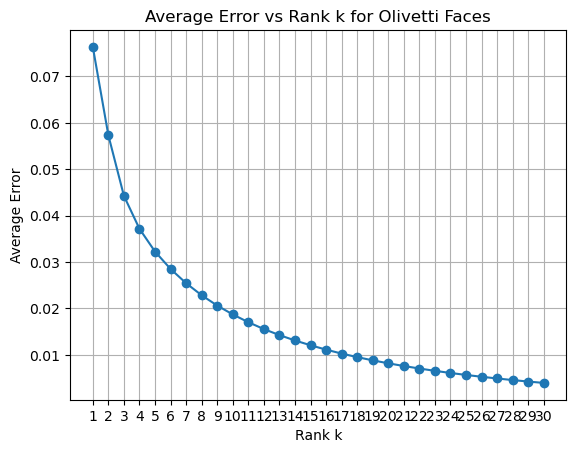

In [63]:
K = range(1, 31)
ae = []

for k in K:
    av_error = computer_average_error_for_images(faces, k)
    ae.append(av_error)

plt.plot(K, ae, marker='o')
plt.xlabel('Rank k')
plt.ylabel('Average Error')
plt.title('Average Error vs Rank k for Olivetti Faces')
plt.xticks(K)
plt.grid()
plt.show()


1. b) Pick any image in the dataset, and display the following side-by-side as
images: the original, and the best rank-k approximations for k = 10, 20, 30, 40. You will
find the imshow method in matplotlib useful for this; pass in cmap=‘gray’ to render
in grayscale. Feel free to play around further with higher resolution images to see the
progression more clearly

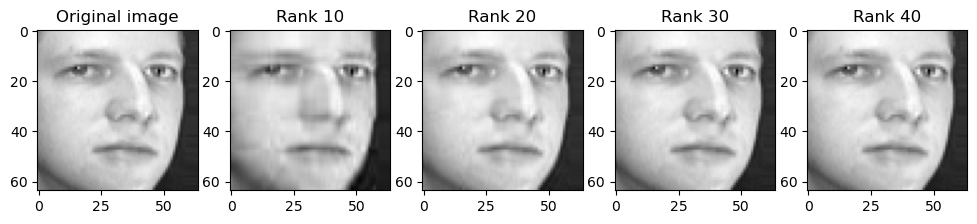

In [64]:
img = faces.images[4]

U, S, Vt = svd_compute(img)
K = [10, 20, 30, 40]
Ms = [svd_compute_k(img, k) for k in K]

plt.figure(figsize=(12, 6)) 
plt.subplot(1, 5, 1) 
plt.imshow(img, cmap='gray') 
plt.title("Original image") 

for i, k in enumerate(K): 
    plt.subplot(1, 5, i+2) 
    plt.imshow(Ms[i], cmap='gray') 
    plt.title(f"Rank {k}") 

plt.show()

2. In this problem we visualize the Wisconsin breast cancer dataset in two dimensions using PCA. First, rescale the data so that every feature has mean...

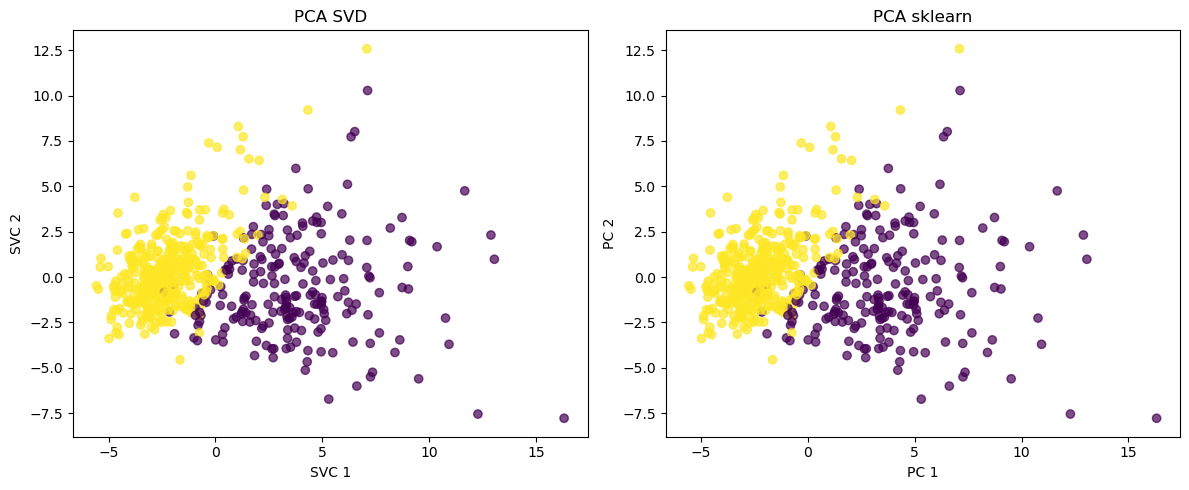

In [65]:
def adjust_signs(A, B): 
    A2 = np.array(A)
    for i in range(A.shape[1]): 
        if np.dot(A2[:, i], B[:, i]) < 0: A2[:, i] *= -1 
    return A2

cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

U, S, Vt = svd_compute(X_scaled)

V = Vt.T
X_svc = X_scaled @ V[:, :2]

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

X_svc = adjust_signs(X_svc, X_pca_sklearn)

plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.scatter(X_svc[:, 0], X_svc[:, 1], c=y, alpha=0.7) 
plt.title("PCA SVD") 
plt.xlabel("SVC 1") 
plt.ylabel("SVC 2") 

plt.subplot(1, 2, 2) 
plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], c=y, alpha=0.7) 
plt.title("PCA sklearn") 
plt.xlabel("PC 1") 
plt.ylabel("PC 2") 

plt.tight_layout() 
plt.show()
